In [2]:
from utils.env import *
from utils.policy import *
from utils.evaluation import *
from utils.action_value import *
from utils.gridworld_util import *
from utils.state_value import  *

e=0.01,sa: 100%|██████████| 2000/2000 [00:31<00:00, 63.54it/s]


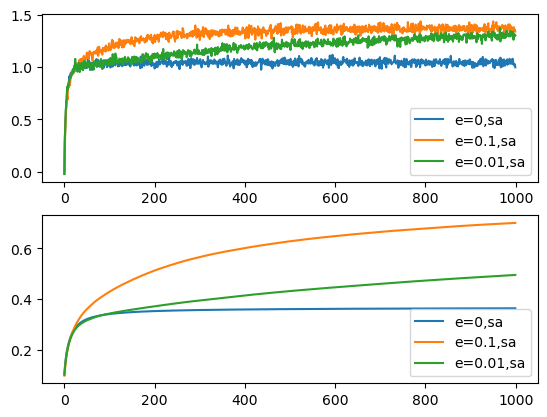

In [ ]:
# figure 2.2
experiment(
    env_func=lambda: Bandit(k=10),
    policy_funcs=[
        lambda epsilon=epsilon: EpsilonGreedyPolicy(SampleAverageValue(k=10), epsilon=epsilon) for epsilon in [0, 0.1, 0.01]
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

e=0.1,ubcs,a=0.1: 100%|██████████| 2000/2000 [01:58<00:00, 16.82it/s]


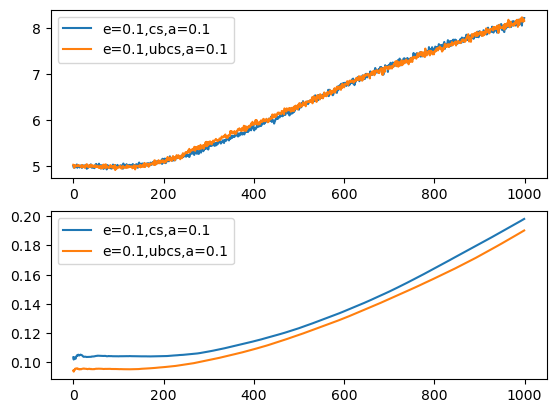

In [3]:
# figure 2.3
experiment(
    env_func=lambda: NonstationaryBandit(k=10, initial_mean=5, evolve_mean=0, evolve_variance=0.01),
    policy_funcs=[
        lambda: EpsilonGreedyPolicy(ConstantStepValue(k=10, a=0.1), epsilon=0.1),
        lambda: EpsilonGreedyPolicy(ConstantStepUnbiasValue(k=10, a=0.1), epsilon=0.1),
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

e=0.1,sa: 100%|██████████| 2000/2000 [01:58<00:00, 16.92it/s]


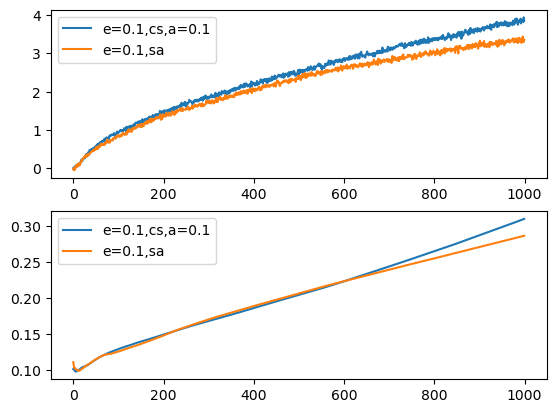

In [4]:
# section 2.5 exercise 2.5
experiment(
    env_func=lambda: NonstationaryBandit(k=10, evolve_mean=0, evolve_variance=0.01),
    policy_funcs=[
        lambda: EpsilonGreedyPolicy(ConstantStepValue(k=10, a=0.1), epsilon=0.1),
        lambda: EpsilonGreedyPolicy(SampleAverageValue(k=10), epsilon=0.1),
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

e=0.1,ubcs,a=0.1: 100%|██████████| 2000/2000 [01:45<00:00, 19.02it/s]


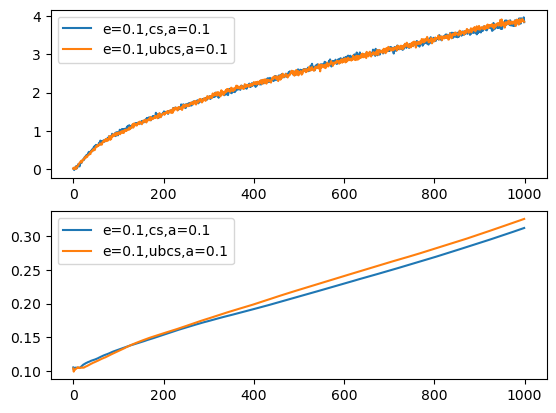

In [5]:
# section 2.6 exercise 2.7
experiment(
    env_func=lambda: NonstationaryBandit(k=10, evolve_mean=0, evolve_variance=0.01),
    policy_funcs=[
        lambda: EpsilonGreedyPolicy(ConstantStepValue(k=10, a=0.1), epsilon=0.1),
        lambda: EpsilonGreedyPolicy(ConstantStepUnbiasValue(k=10, a=0.1), epsilon=0.1),
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

e=0.1,sa: 100%|██████████| 2000/2000 [00:29<00:00, 66.98it/s]


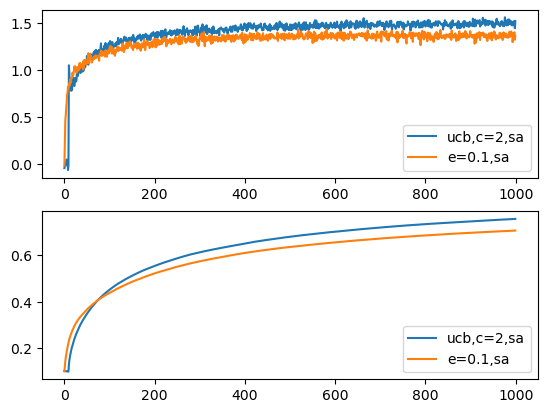

In [6]:
# figure 2.4
experiment(
    env_func=lambda: Bandit(k=10),
    policy_funcs=[
        lambda: UpperConfidenceBoundPolicy(SampleAverageValue(k=10), c=2),
        lambda: EpsilonGreedyPolicy(SampleAverageValue(k=10), epsilon=0.1),
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

g,a=0.4,b=0: 100%|██████████| 2000/2000 [01:13<00:00, 27.20it/s]


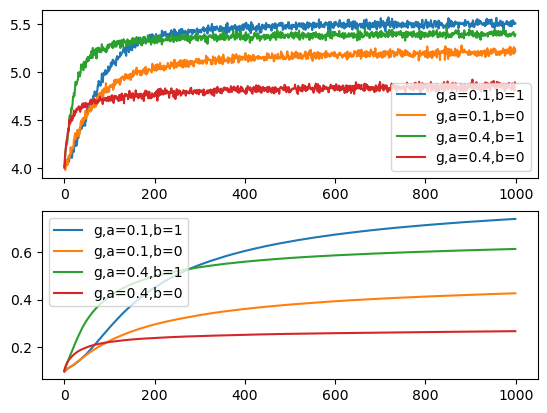

In [7]:
# figure 2.5
experiment(
    env_func=lambda: Bandit(k=10, initial_mean=4),
    policy_funcs=[
        lambda a=a, with_baseline=with_baseline: GradientPolicy(SampleAverageValue(k=10), k=10, a=a, with_baseline=with_baseline)
        for a in [.1, .4] for with_baseline in [True, False]
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

g,a=0.4,b=0: 100%|██████████| 2000/2000 [01:10<00:00, 28.56it/s]


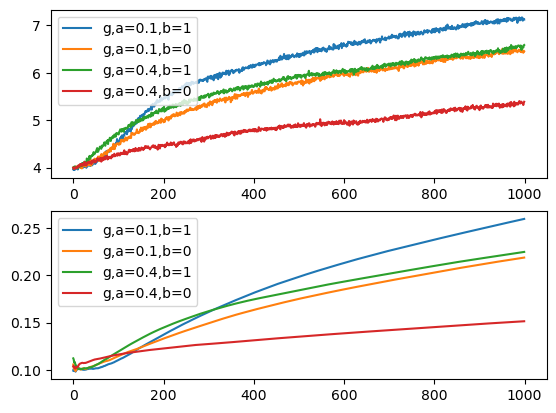

In [8]:
# figure 2.5
experiment(
    env_func=lambda: NonstationaryBandit(k=10, initial_mean=4, evolve_mean=0, evolve_variance=0.01),
    policy_funcs=[
        lambda a=a, with_baseline=with_baseline: GradientPolicy(ConstantStepValue(k=10, a=0.1), k=10, a=a, with_baseline=with_baseline)
        for a in [.1, .4] for with_baseline in [True, False]
    ],
    runs=2000,
    horizon=1000,
    need_best_ratio=True,
)

ucb,c=4,sa: 100%|██████████| 2000/2000 [00:32<00:00, 60.99it/s]


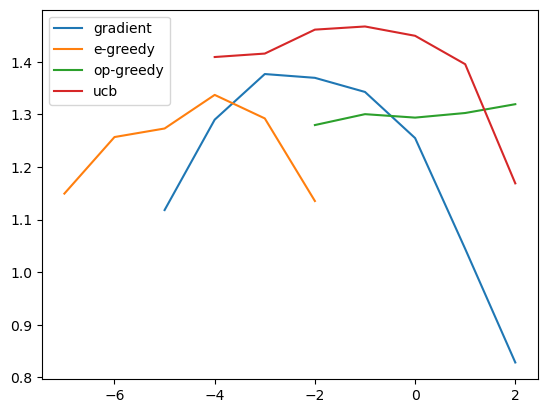

In [9]:
# figure 2.6
banchmark(
    k=10,
    env_func=lambda: Bandit(k=10),
    plans={
        'gradient': [[exponent, lambda exponent=exponent: GradientPolicy(SampleAverageValue(k=10), k=10, a=2**exponent, with_baseline=True)] for  exponent in range(-5, 3)],
        'e-greedy': [[exponent, lambda exponent=exponent: EpsilonGreedyPolicy(SampleAverageValue(k=10), k=10, epsilon=2**exponent)] for exponent in range(-7, -1)],
        'op-greedy': [[exponent, lambda exponent=exponent: EpsilonGreedyPolicy(SampleAverageValue(k=10), k=10, epsilon=.1, initial_mean=2**exponent)] for exponent in range(-2, 3)],
        'ucb': [[exponent, lambda exponent=exponent: UpperConfidenceBoundPolicy(SampleAverageValue(k=10), k=10, c=2**exponent)] for exponent in range(-4, 3)],
    },
    runs=2000,
)

ucb,c=4,cs,a=0.1: 100%|██████████| 2000/2000 [00:51<00:00, 39.17it/s]


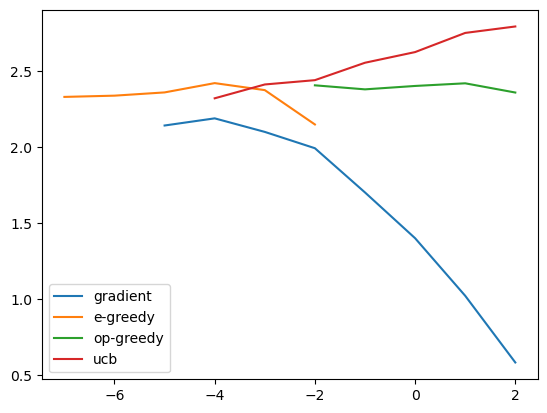

In [10]:
# section 2.10 exercise 2.11
banchmark(
    k=10,
    env_func=lambda: NonstationaryBandit(k=10, evolve_mean=0, evolve_variance=0.01),
    plans={
        'gradient': [[exponent, lambda exponent=exponent: GradientPolicy(ConstantStepValue(k=10, a=.1), k=10, a=2**exponent, with_baseline=True)] for  exponent in range(-5, 3)],
        'e-greedy': [[exponent, lambda exponent=exponent: EpsilonGreedyPolicy(ConstantStepValue(k=10, a=.1), k=10, epsilon=2**exponent)] for exponent in range(-7, -1)],
        'op-greedy': [[exponent, lambda exponent=exponent: EpsilonGreedyPolicy(ConstantStepValue(k=10, a=.1), k=10, epsilon=.1, initial_mean=2**exponent)] for exponent in range(-2, 3)],
        'ucb': [[exponent, lambda exponent=exponent: UpperConfidenceBoundPolicy(ConstantStepValue(k=10, a=.1), k=10, c=2**exponent)] for exponent in range(-4, 3)],
    },
    runs=2000,
    horizon=1000
)

In [4]:
# section 3.5
class GridWorldStateValue_3_5(AnalyticalStateValue):

    def p(self, s, a):
        row, col = s
        if row == 0 and col == 1:
            return [Transition((4, 1), 10, 1)]
        elif row == 0 and col == 3:
            return [Transition((2, 3), 5, 1)]
        else:
            row += a[0]
            col += a[1]
            if row < 0 or row >= self.size[0] or col < 0 or col >= self.size[1]:
                return [Transition(s, -1, 1)]
            else:
                return [Transition((row, col), 0, 1)]


print_matrix(GridWorldStateValue_3_5(size=(5, 5), tau=0.9, state_space=tabular_states((5, 5)), action_space=action_space)(round=1))

     0    1    2    3    4
0  3.3  8.8  4.4  5.3  1.5
1  1.5  3.0  2.3  1.9  0.5
2  0.1  0.7  0.7  0.4 -0.4
3 -1.0 -0.4 -0.4 -0.6 -1.2
4 -1.9 -1.3 -1.2 -1.4 -2.0


In [ ]:
# example 4.1
class GridWorldStateValue_4_1(AnalyticalStateValue):

    def p(self, s, a):
        row, col = s[0] + a[0], s[1] + a[1]
        return [Transition((int(np.clip(row, 0, self.size[0]-1)), int(np.clip(col, 0, self.size[1]-1))), -1, 1)]


print_matrix(GridWorldStateValue_4_1(size=(4, 4), tau=1, state_space=[to_coordinate(n, size=(4, 4)) for n in range(1, 15)], action_space=action_space)(round=1))

      0     1     2     3
0   0.0 -14.0 -20.0 -22.0
1 -14.0 -18.0 -20.0 -20.0
2 -20.0 -20.0 -18.0 -14.0
3 -22.0 -20.0 -14.0   0.0


In [7]:
# example 4.1
class GridWorldStateValue_4_1(IterativeStateValue):

    def p(self, s, a, nrow=None, ncol=None):
        nrow = nrow or self.size[0]
        ncol = ncol or self.size[1]
        row, col = s[0] + a[0], s[1] + a[1]
        return [Transition((int(np.clip(row, 0, nrow-1)), int(np.clip(col, 0, ncol-1))), -1, 1)]


gridworld = GridWorldStateValue_4_1(size=(4, 4), tau=1, state_space=[to_coordinate(n, size=(4, 4)) for n in range(1, 15)], action_space=action_space, action_name=action_name)
V = gridworld(round=3)
pi = gridworld.value_policy(V)
gridworld.print_policy(pi)

State Policy Evaluation:   9%|▊         | 87/1000 [00:00<00:00, 948.91it/s]

    0   1   2   3
0       ←   ←  ←↓
1   ↑  ↑←  ←↓   ↓
2   ↑  ↑→  →↓   ↓
3  ↑→   →   →    


In [19]:
# section 4.1 exercise 4.2
class GridWorldStateValue_4_1_Exercise_1(GridWorldStateValue_4_1):

    def p(self, s, a):
        if s[0] < self.size[0] - 1:
            return super().p(s, a, nrow=self.size[0] - 1)

        elif s == (4, 1):
            if a == (0, -1):
                return [Transition(to_coordinate(12, size=self.size), -1, 1)]
            elif a == (-1, 0):
                return [Transition(to_coordinate(13, size=self.size), -1, 1)]
            elif a == (0, 1):
                return [Transition(to_coordinate(14, size=self.size), -1, 1)]
            elif a == (1, 0):
                return [Transition(s, -1, 1)]


class GridWorldStateValue_4_1_Exercise_2(GridWorldStateValue_4_1_Exercise_1):

    def p(self, s, a):
        if s == (3, 1) and a == (1, 0):
            return [Transition(to_coordinate(17, size=self.size), -1, 1)]
        else:
            return super().p(s, a)


if __name__ == "__main__":
    gridworld = GridWorldStateValue_4_1_Exercise_1(size=(5, 4), tau=1, state_space=[to_coordinate(n, size=(4, 4)) for n in range(1, 15)] + [(4, 1)], action_space=action_space, action_name=action_name)
    print_matrix(gridworld(round=2))

    gridworld = GridWorldStateValue_4_1_Exercise_2(size=(5, 4), tau=1, state_space=[to_coordinate(n, size=(4, 4)) for n in range(1, 15)] + [(4, 1)], action_space=action_space, action_name=action_name)
    print_matrix(gridworld(round=2))

State Policy Evaluation:   9%|▊         | 87/1000 [00:00<00:02, 431.11it/s]


       0      1      2      3
0   0.00 -13.99 -19.99 -21.99
1 -13.99 -17.99 -19.99 -19.99
2 -19.99 -19.99 -17.99 -13.99
3 -21.99 -19.99 -13.99   0.00
4   0.00 -19.99   0.00   0.00


State Policy Evaluation:   9%|▊         | 87/1000 [00:00<00:01, 826.30it/s]

       0      1      2      3
0   0.00 -13.99 -19.99 -21.99
1 -13.99 -17.99 -19.99 -19.99
2 -19.99 -19.99 -17.99 -13.99
3 -21.99 -19.99 -13.99   0.00
4   0.00 -19.99   0.00   0.00
